# Spatial Deconvolution
### SpatialDecon
**Author:** Diana Vera Cruz


## Goal

Spatial Deconvolution infers cell abundance per cell type in each segment, based on a reference matrix. This method does not incorporate the spatial context for a given segment, rather infers cell types abundances based on expression, and if nuclei counts are available, it can be used to adjust the cell type abundances.

## Steps:

You can start with a "NanoStringGeoMxSet" or a "Seurat" object.

In [2]:
out_dir = './GeoMx'

In [3]:
## cd /gpfs/data/biocore-workshop/spatial_transcriptomics_bruker_2026_workshop2
##sbatch --mem=10G  ./launch_jupyter_conda.sh /gpfs/data/biocore-workshop/spatial_transcriptomics_bruker_2026_workshop2/conda_envs/geomx_env

library(tidyverse)
library(SpatialDecon)
library(GeomxTools)
library(ComplexHeatmap)

geomx = readRDS(file.path('/gpfs/data/biocore-workshop/spatial_transcriptomics_bruker_2026_workshop2/GeoMx/results', 'tidy_geomx_obj.rds'))

## Outdir -> set the results folder. 
out_dir = file.path(out_dir, 'results')
if(!dir.exists( out_dir )) dir.create( out_dir, recursive = T)

## Initial normalization: Q3, Upperquartile normalization.
geomx <- normalize(geomx, 
                     fromElt = "exprs",
                     norm_method = "quant", 
                     desiredQuantile = .75,
                     toElt = "q_norm")

## Add Assumed cell type: Combination of region + segment. 
protocolData(geomx)$celltype = with(sData(geomx),  
     case_when(segment == 'Geometric Segment' ~ 'Glomeruli', 
               segment == 'PanCK-' ~ 'Distal\nTubules', 
               TRUE ~ 'Proximal\nTubules'))

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.2
✔ ggplot2   4.0.2     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: Biobase

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:lubridate’:

    intersect, setdiff, union


The following objects are masked from ‘package:dplyr’:

    combine, intersect, setdiff, union


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append,

### 1. Calculate Background (Optional)

This requires the presence of Negative Probes in the dataset.

**Input** \* norm: Normalized expression matrix (Linear scale) \* probepool: Probeset names \* negnames: Negative control probeset names

In [4]:
## Calculate background for data-set: Based in Negative Control Probes. For each probeset, one value in negnames. 
##Check the negative control probes in the dataset, NegProbe prefix expected for most probesets. 
dplyr::select( fData(geomx), Module, TargetName) %>% filter(grepl('NegProbe', TargetName))

bg = derive_GeoMx_background(norm = geomx@assayData$q_norm,
                             probepool = fData(geomx)$Module,
                             negnames = c("NegProbe-WTX"))

,Module,TargetName
,<chr>,<chr>
NegProbe-WTX,TAP_H_WTA_v1.0,NegProbe-WTX


### 2. Cell Profile matrix

#### Predefined tables: Human/Mouse Atlas from Nanostring

In this case we will use the Kidney Dataset, which is the closest to our dataset.  
The profile matrix is (genes * cell_types) in size, and is the base for the deconvolution process. This methos is not spatially-aware, rather is completely based on expression patterns. 

In [13]:
## Obtained from https://github.com/Nanostring-Biostats/CellProfileLibrary/tree/master
human_kidney <- download_profile_matrix(species = "Human",
                                       age_group = "Adult", 
                                       matrixname = "Kidney_HCA")

dim(human_kidney)

[1] 16358    33

In [22]:
ix = rowSums(human_kidney) 

summary( ix )

quantile(ix, probs = c(0.1, 0.9, 0.95))

sum(ix > 48.79)

    Min.  1st Qu.   Median     Mean  3rd Qu.     Max. 
  0.0001   1.4383   5.7022  13.9933  13.8396 602.7569 

10%        90%        95% 
 0.1747447 29.5686363 48.7922432

[1] 818

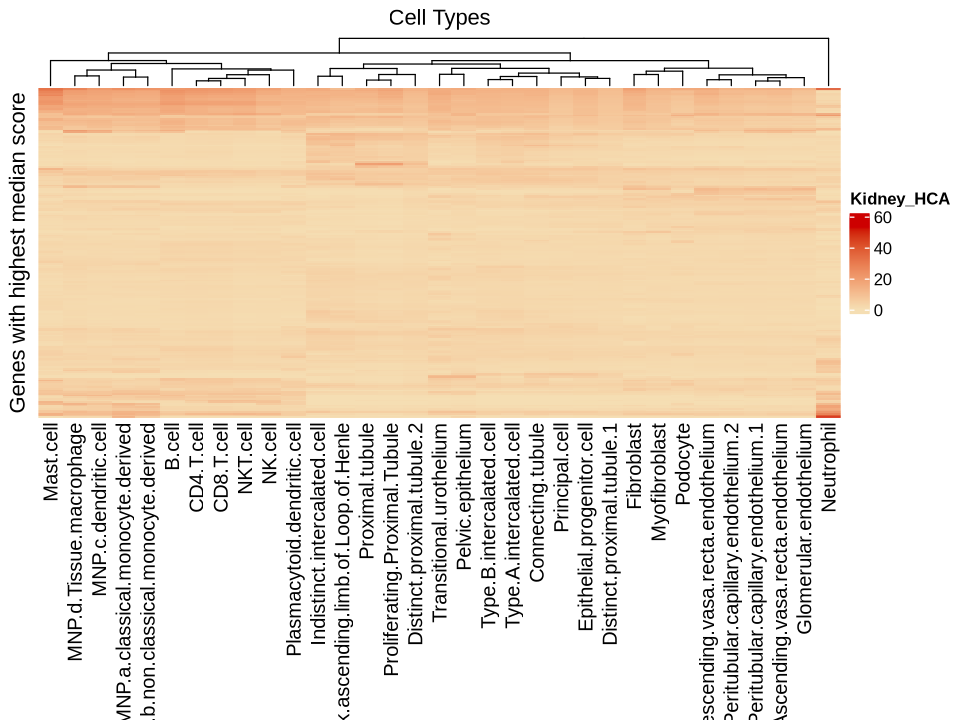

In [27]:
## Plot size
options(repr.plot.width=8, repr.plot.height=6)

Heatmap(human_kidney[ix > 48.79,], name = 'Kidney_HCA', col = c('wheat', 'red3'),
        show_column_dend = T, show_row_dend = F, use_raster = T, show_row_names = F, show_column_names = T, 
        row_title = 'Genes with highest median score', column_title = 'Cell Types')

#### Custom reference matrix.

You can also create a custom reference matrix derived from a set you annotated previously. The functions for this are included in [Bioconductor: SpatialDecon_vignette](https://bioconductor.org/packages/release/bioc/vignettes/SpatialDecon/inst/doc/SpatialDecon_vignette_NSCLC.html){.uri}

### Run deconvolution

The key result is the beta matrix, that reflects the cell type abundance per segment. 

When the number of cells (~ nuclei) is available, beta reflects the estimated number of cells belonging to a given cell type. 

When no cell number is provided, beta will include relative abundance scores, but you will need to normalize so the values per segment sum to 1 to get a estimate of proportion of cells per cell type in the segment.

**Wrapper function. - Version without cell number and omitting background computation.**

```
res = runspatialdecon(
  object = geomx, 
  norm_elt = 'q_norm', 
  raw_elt = 'exprs',
  X = human_kidney, ## Reference matrix
)

beta_mx = res$beta
```

In [29]:
res = spatialdecon(
  norm = geomx@assayData$q_norm, 
  bg = bg,
  X = human_kidney, ## Reference matrix
  raw = geomx@assayData$exprs,
  cell_counts = sData(geomx)$nuclei 
)

beta_mx = res$beta
## Cell

###  Cell type proportions per AOI

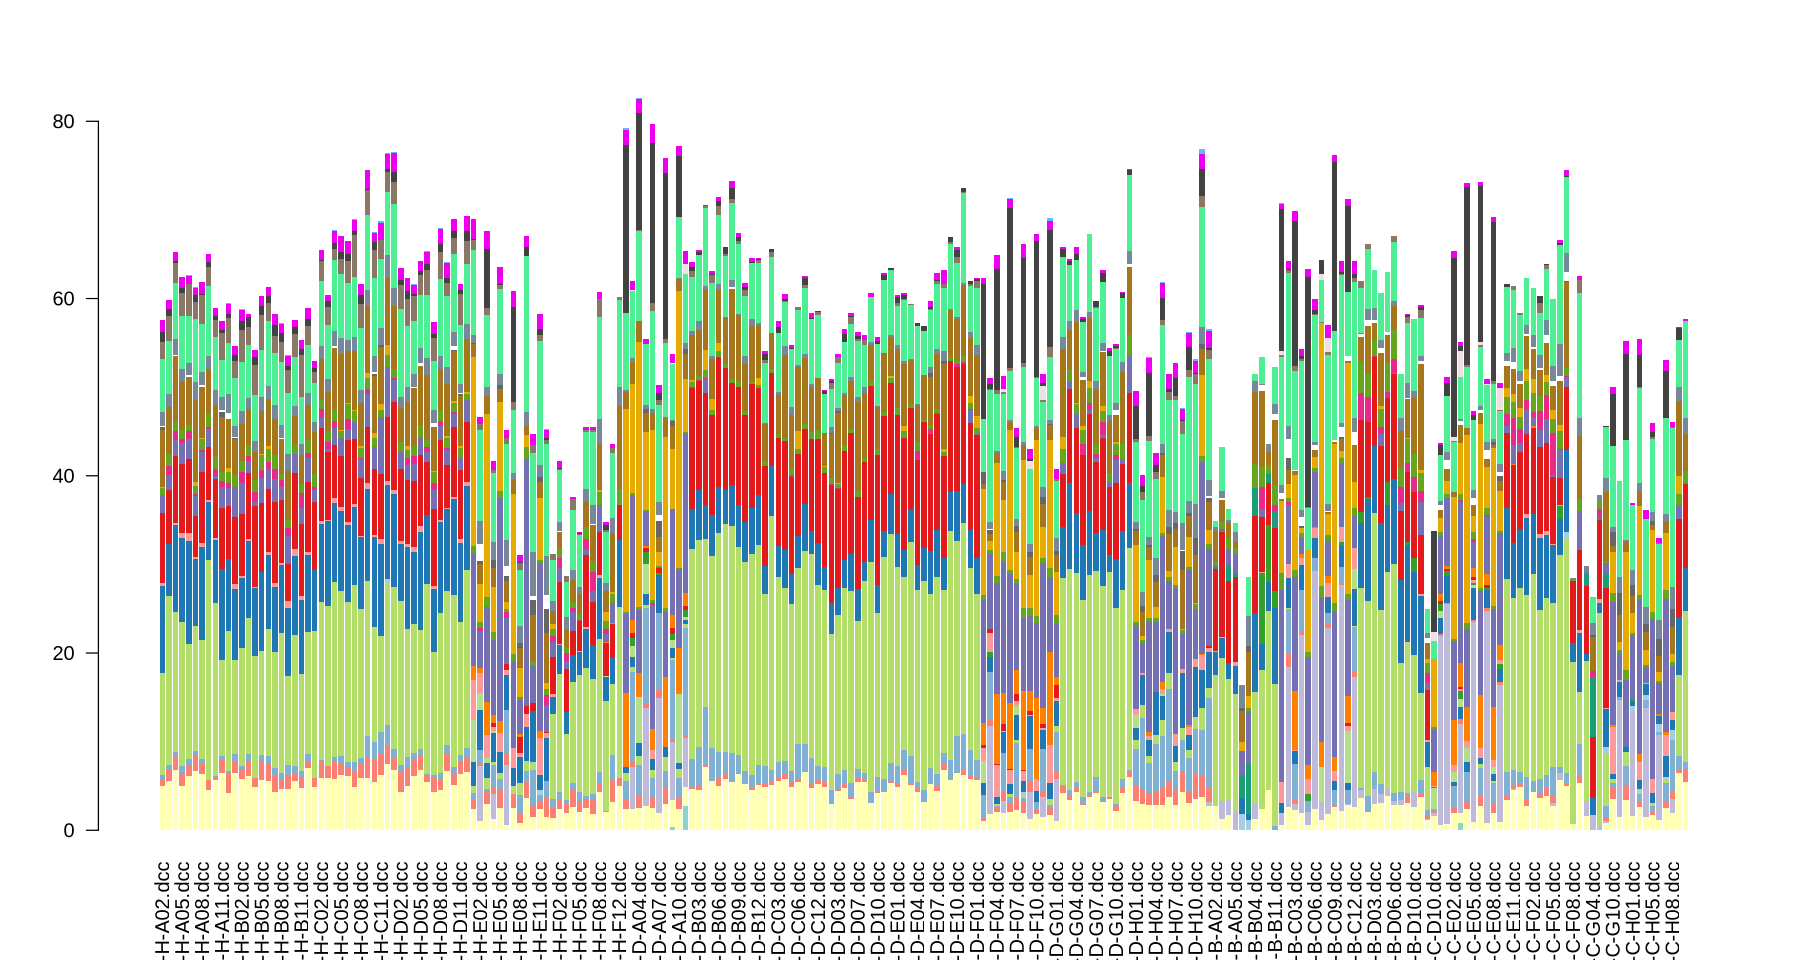

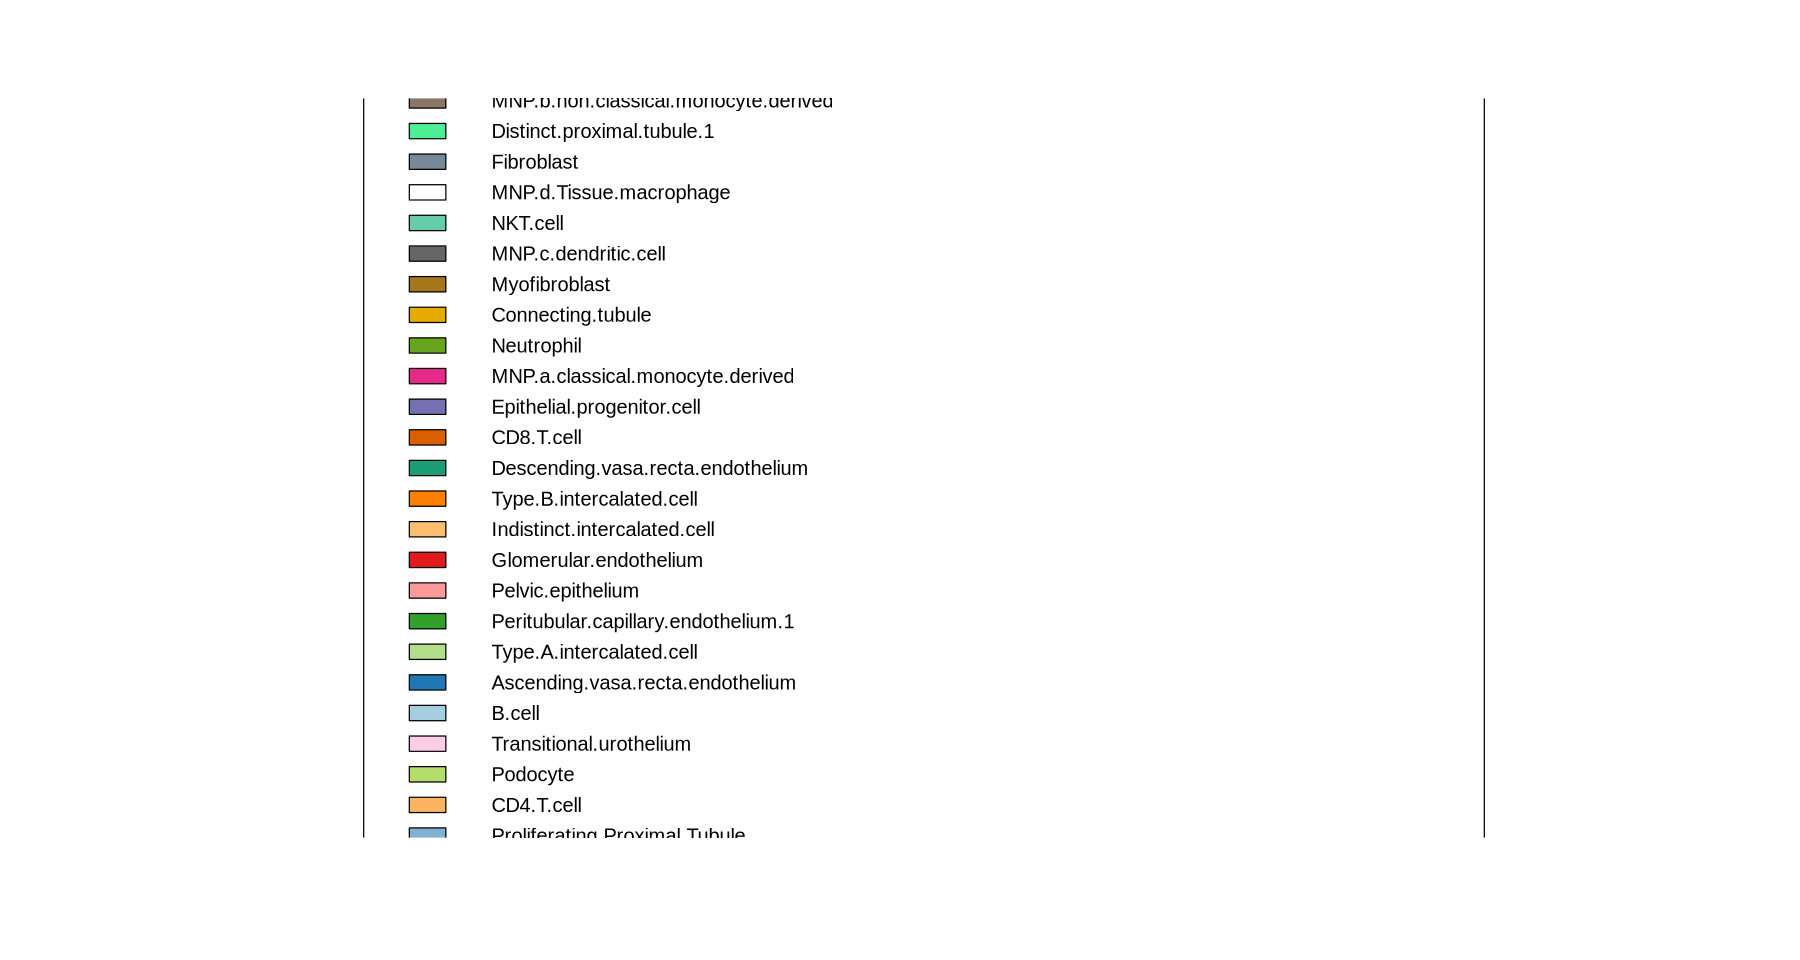

In [30]:
options(repr.plot.width = 15, repr.plot.height = 8)



TIL_barplot(mat = (beta_mx), draw_legend = T)

In [42]:
prop_beta = apply(beta_mx,2, function(x) x/sum(x)) 

In [52]:
dplyr::count( sData(geomx), segment, celltype)

segment,celltype,n
<chr>,<chr>,<int>
Geometric Segment,Glomeruli,141
PanCK+,Proximal Tubules,39
PanCK-,Distal Tubules,48
WT,Proximal Tubules,3


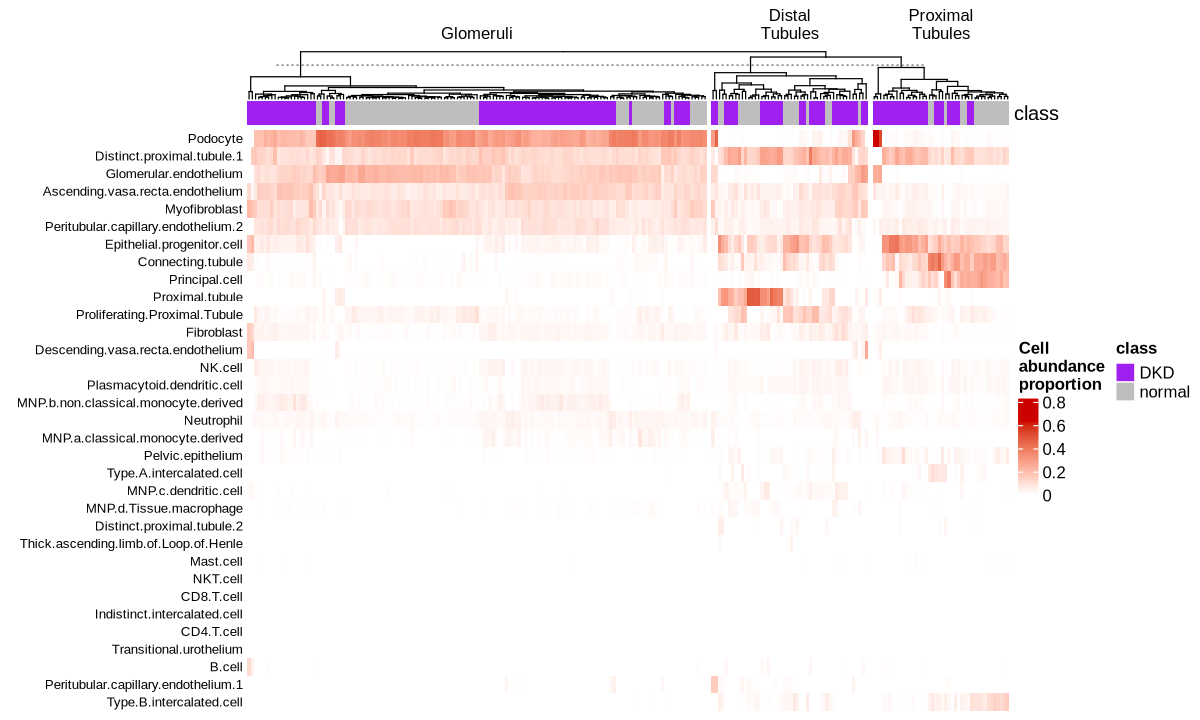

In [47]:
options(repr.plot.width = 10, repr.plot.height = 6)

Heatmap(prop_beta, show_column_names = F, show_row_dend = F,
        col = c('white', 'red3'), name = 'Cell\nabundance\nproportion',
        show_parent_dend_line = T, row_names_side = 'left',
        #show_heatmap_legend = F, 
        row_names_gp = gpar(fontsize = 8), column_title_gp = gpar(fontsize = 10),
        top_annotation = HeatmapAnnotation(df = dplyr::select(sData(geomx), class), 
                                           col = list(class = c(DKD = 'purple', normal = 'grey'))),
        column_split = sData(geomx)$celltype)

In [53]:
## Write output table: 
write_tsv(as.data.frame(beta_mx) %>% rownames_to_column('CellType'), file.path(out_dir, 'SpatialDecon_CellAbundance.tsv'))

## Proportions.
write_tsv(as.data.frame(prop_beta) %>% rownames_to_column('CellType'), file.path(out_dir, 'SpatialDecon_CellAbundance_proportions.tsv'))